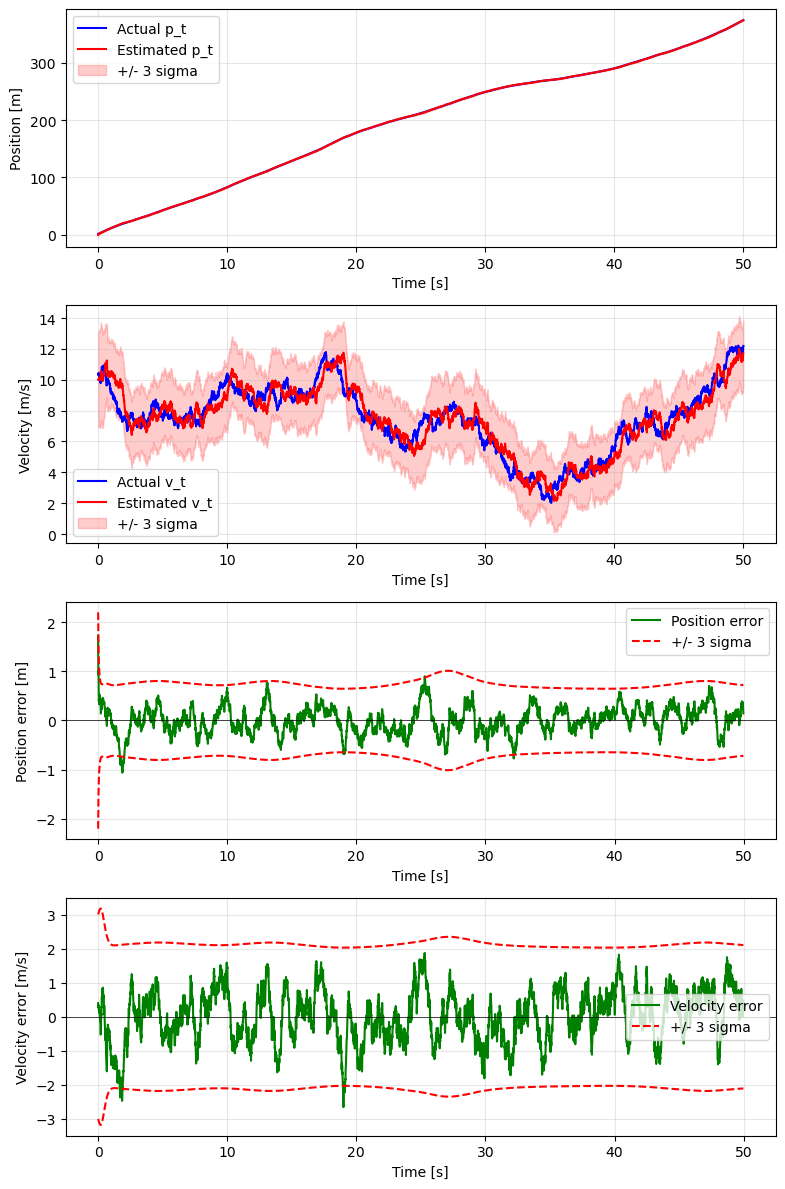

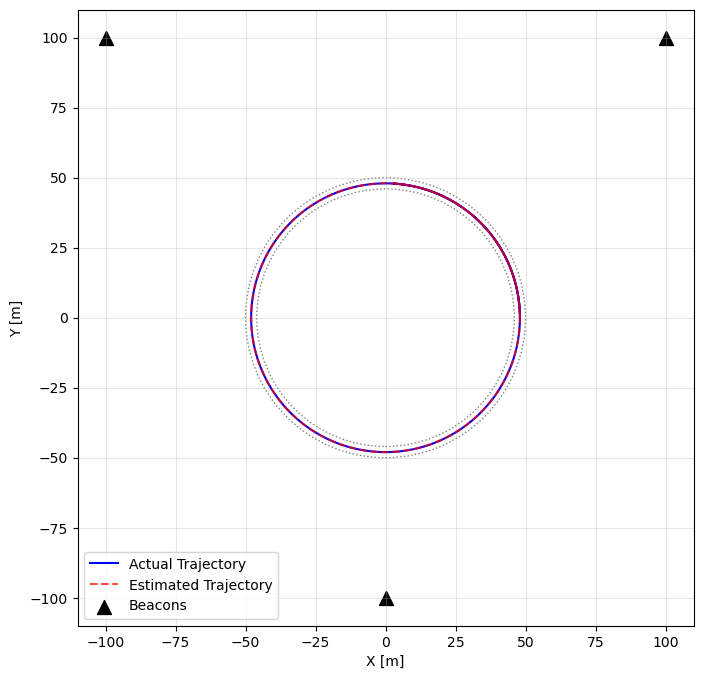

In [16]:
import numpy as np
import casadi as cs
import matplotlib.pyplot as plt

np.random.seed(0)

# Problem parameters
h = 0.01  # 100Hz beacon freq
Q = 0.01  # Small Q, assume constant longitudinal velocity (approx 10m/s)
R = 1.5**2  # Measurement noise variance

# Linear dynamics matrices (arc length and velocity)
A = np.array([[1, h], [0, 1]])
G = np.array([[0], [1]])

# Assume the vehicle stays exactly at the center of the lane
R_c = 48.0 

# Place beacons to avoid ambiguity: 2 outside, 1 inside
beacons = np.array([
    [0, -100],      
    [100, 100],    
    [-100, 100]    
])
ny = len(beacons)
R_mat = R * np.eye(ny)

# Assume initial state is relatively well known (small P0)
x0_tilde = np.array([[0], [10]]) 
P0 = np.array([[1, 0], [0, 1]])  

# CasADi symbolic variables for nonlinear measurement model
x_sym = cs.SX.sym('x', 2)
v_sym = cs.SX.sym('v', ny)

p_t = x_sym[0]
pos_x = R_c * cs.cos(p_t / R_c)
pos_y = R_c * cs.sin(p_t / R_c)

h_list = []
for i in range(ny):
    bx = beacons[i, 0]
    by = beacons[i, 1]
    # Nonlinear distance formula
    dist = cs.sqrt((pos_x - bx)**2 + (pos_y - by)**2)
    h_list.append(dist + v_sym[i])

h_sym = cs.vertcat(*h_list)

# Jacobian for EKF
jhx = cs.Function('jhx', [x_sym, v_sym], [cs.jacobian(h_sym, x_sym)])
h_func = cs.Function('h_func', [x_sym, v_sym], [h_sym])

def measurement_update(sigma_tu, x_tu, y):
    C_mat = np.array(jhx(x_tu, np.zeros(ny))).astype(float)
    Z = C_mat @ sigma_tu @ C_mat.T + R_mat
    y_pred = np.array(h_func(x_tu, np.zeros(ny))).flatten()
    
    x_mu = x_tu + (sigma_tu @ C_mat.T @ np.linalg.solve(Z, y - y_pred)).reshape(-1, 1)
    sigma_mu = sigma_tu - sigma_tu @ C_mat.T @ np.linalg.solve(Z, C_mat @ sigma_tu)
    return sigma_mu, x_mu

def time_update(sigma_mu, x_mu):
    x_tu = A @ x_mu
    sigma_tu = A @ sigma_mu @ A.T + Q * (G @ G.T)
    return sigma_tu, x_tu

n_sim = 5000
x = np.random.multivariate_normal(x0_tilde.flatten(), P0, 1).reshape((-1,1))
sigma_tu, x_tu = P0, x0_tilde.copy()

x_cache = np.zeros((n_sim, 2))
x_mu_cache = np.zeros((n_sim-1, 2))
sigma_mu_cache = np.zeros((n_sim-1, 2, 2))
x_cache[0, :] = x.T

# EKF main loop
for t in range(n_sim - 1):
    # Assume Gaussian noise for both measurement and process
    v = np.random.normal(0, np.sqrt(R), ny)
    y = np.array(h_func(x, v)).flatten()
    
    sigma_mu, x_mu = measurement_update(sigma_tu, x_tu, y)
    
    x_mu_cache[t, :] = x_mu.flatten()
    sigma_mu_cache[t] = sigma_mu
    
    sigma_tu, x_tu = time_update(sigma_mu, x_mu)
    
    w = np.random.normal(0, np.sqrt(Q))
    x = A @ x + G * w
    x_cache[t+1, :] = x.T

t_axis = np.arange(n_sim) * h

sigma_p  = np.sqrt(sigma_mu_cache[:, 0, 0])
sigma_vv = np.sqrt(sigma_mu_cache[:, 1, 1])

# Plot 1: States and Errors (1D perspective)
fig1, axs = plt.subplots(4, 1, figsize=(8, 12))

axs[0].plot(t_axis, x_cache[:, 0], 'b-', label='Actual p_t')
axs[0].plot(t_axis[:-1], x_mu_cache[:, 0], 'r-', label='Estimated p_t')
axs[0].fill_between(t_axis[:-1], x_mu_cache[:, 0] - 3*sigma_p,
                    x_mu_cache[:, 0] + 3*sigma_p, alpha=0.2, color='red', label='+/- 3 sigma')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Position [m]')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(t_axis, x_cache[:, 1], 'b-', label='Actual v_t')
axs[1].plot(t_axis[:-1], x_mu_cache[:, 1], 'r-', label='Estimated v_t')
axs[1].fill_between(t_axis[:-1], x_mu_cache[:, 1] - 3*sigma_vv,
                    x_mu_cache[:, 1] + 3*sigma_vv, alpha=0.2, color='red', label='+/- 3 sigma')
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Velocity [m/s]')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

axs[2].plot(t_axis[:-1], x_cache[:-1, 0] - x_mu_cache[:, 0], 'g-', label='Position error')
axs[2].plot(t_axis[:-1],  3*sigma_p, 'r--', label='+/- 3 sigma')
axs[2].plot(t_axis[:-1], -3*sigma_p, 'r--')
axs[2].axhline(0, color='k', linewidth=0.5)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('Position error [m]')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

axs[3].plot(t_axis[:-1], x_cache[:-1, 1] - x_mu_cache[:, 1], 'g-', label='Velocity error')
axs[3].plot(t_axis[:-1],  3*sigma_vv, 'r--', label='+/- 3 sigma')
axs[3].plot(t_axis[:-1], -3*sigma_vv, 'r--')
axs[3].axhline(0, color='k', linewidth=0.5)
axs[3].set_xlabel('Time [s]')
axs[3].set_ylabel('Velocity error [m/s]')
axs[3].legend()
axs[3].grid(True, alpha=0.3)

plt.tight_layout()

# Plot 2: 2D Trajectory Map
fig2, ax2 = plt.subplots(figsize=(8, 8))
theta_true = x_cache[:, 0] / R_c
x_2d_true = R_c * np.cos(theta_true)
y_2d_true = R_c * np.sin(theta_true)

theta_est = x_mu_cache[:, 0] / R_c
x_2d_est = R_c * np.cos(theta_est)
y_2d_est = R_c * np.sin(theta_est)

ax2.plot(x_2d_true, y_2d_true, 'b-', label='Actual Trajectory')
ax2.plot(x_2d_est, y_2d_est, 'r--', label='Estimated Trajectory', alpha=0.7)
ax2.scatter(beacons[:, 0], beacons[:, 1], c='k', marker='^', s=100, label='Beacons')

circle_inner = plt.Circle((0, 0), 46, color='gray', fill=False, linestyle=':')
circle_outer = plt.Circle((0, 0), 50, color='gray', fill=False, linestyle=':')
ax2.add_patch(circle_inner)
ax2.add_patch(circle_outer)

ax2.set_aspect('equal')
ax2.set_xlabel('X [m]')
ax2.set_ylabel('Y [m]')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

Step 3 simulation completed successfully using integrated 2D model.


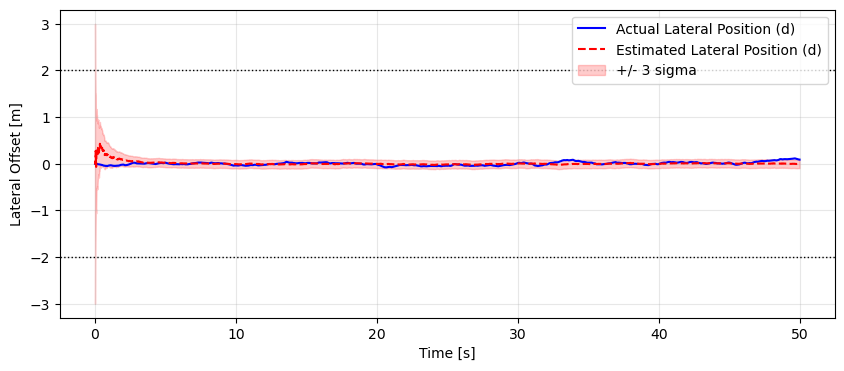

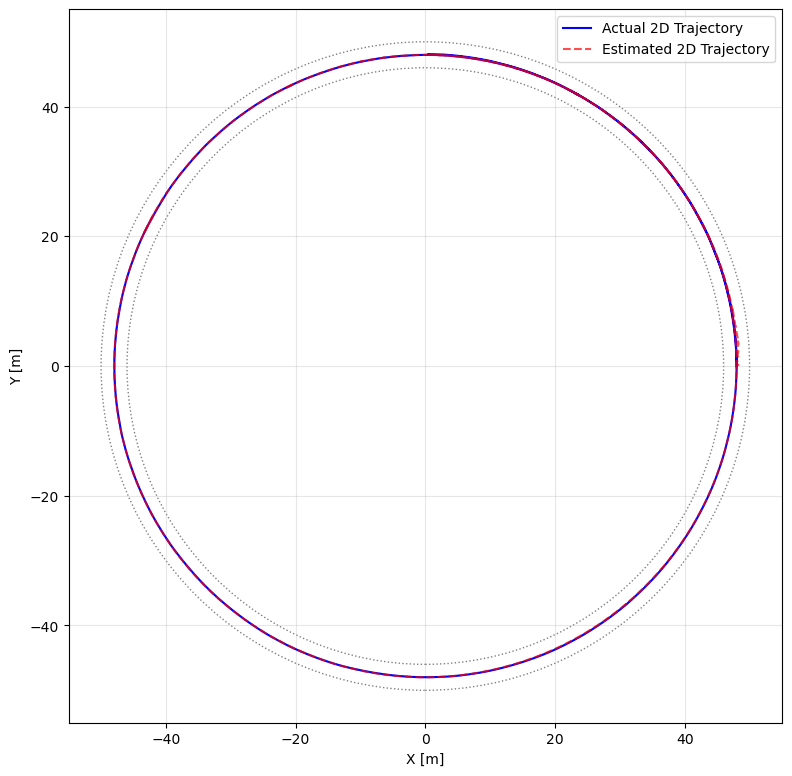

In [17]:
import casadi.casadi as cs
import numpy as np
import matplotlib.pyplot as plt

# Step 3: 2D Motion Model Integration

# 1. Setup Parameters 
# Matching the sampling time 'h' from Step 2
dt = 0.01 
R_c = 48.0 

# 2. Define CasADi Symbolic Variables (4-state model)
s = cs.MX.sym('s')       
v_s = cs.MX.sym('v_s')   
d = cs.MX.sym('d')       
v_d = cs.MX.sym('v_d')   
x_sym = cs.vertcat(s, v_s, d, v_d)

w_vs = cs.MX.sym('w_vs')
w_vd = cs.MX.sym('w_vd')
w_sym = cs.vertcat(w_vs, w_vd)

# 3. Lateral motion parameters
k_restore = 0.05
k_damp = 0.9
k_vel = 0.1
v_target = 10.0

# 4. Define Prediction Dynamics
s_next = s + v_s * dt
v_s_next = v_s + k_vel * (v_target - v_s) * dt + w_vs
d_next = d + v_d * dt
v_d_next = k_damp * v_d - k_restore * d + w_vd

x_next = cs.vertcat(s_next, v_s_next, d_next, v_d_next)

f_dynamics = cs.Function('f_dynamics', [x_sym, w_sym], [x_next])
A_jac = cs.Function('A_jac', [x_sym, w_sym], [cs.jacobian(x_next, x_sym)])
G_jac = cs.Function('G_jac', [x_sym, w_sym], [cs.jacobian(x_next, w_sym)])

# 5. Covariance Matrices
Q_step3 = np.diag([0.1, 0.001]) 
R_step3 = np.diag([1.0, 1.0]) 

# 6. EKF Simulation Loop
w_mean = np.zeros((2, 1))

# Initialize cache using n_sim from Step 2
x_mu_cache_3 = np.zeros((n_sim, 4))
P_cache_3 = np.zeros((n_sim, 4, 4))
x_true_cache_3 = np.zeros((n_sim, 4))

# Initial state setup
x_true_3 = np.array([0.0, 10.0, 0.0, 0.0])
x_mu_cache_3[0, :] = x_true_3
P_cache_3[0, :, :] = np.eye(4)
x_true_cache_3[0, :] = x_true_3

for t in range(n_sim - 1):
    
    # True state simulation
    w_true = np.random.multivariate_normal([0, 0], Q_step3)
    x_true_3 = np.array(f_dynamics(x_true_3, w_true)).flatten()
    x_true_cache_3[t+1, :] = x_true_3
    
    # Measurement generation
    v_true = np.random.multivariate_normal([0, 0], R_step3)
    H_val = np.zeros((2, 4))
    H_val[0, 0] = 1.0 
    H_val[1, 2] = 1.0 
    y_curr = H_val @ x_true_3 + v_true
    
    # Time update
    x_curr = x_mu_cache_3[t, :]
    P_curr = P_cache_3[t, :, :]
    
    x_pred = np.array(f_dynamics(x_curr, w_mean)).flatten()
    
    A_val = np.array(A_jac(x_curr, w_mean))
    G_val = np.array(G_jac(x_curr, w_mean))
    
    P_pred = A_val @ P_curr @ A_val.T + G_val @ Q_step3 @ G_val.T
    
    # Measurement update
    S = H_val @ P_pred @ H_val.T + R_step3
    K = P_pred @ H_val.T @ np.linalg.inv(S)
    
    innovation = y_curr - H_val @ x_pred
    x_updated = x_pred + K @ innovation
    P_updated = (np.eye(4) - K @ H_val) @ P_pred
    
    x_mu_cache_3[t+1, :] = x_updated
    P_cache_3[t+1, :, :] = P_updated

print("Step 3 simulation completed successfully using integrated 2D model.")

# 7. Visualization
t_axis = np.arange(n_sim) * dt

s_true = x_true_cache_3[:, 0]
d_true = x_true_cache_3[:, 2]

s_est = x_mu_cache_3[:, 0]
d_est = x_mu_cache_3[:, 2]

sigma_d = np.sqrt(P_cache_3[:, 2, 2])

fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(t_axis, d_true, color='blue', label='Actual Lateral Position (d)')
ax3.plot(t_axis, d_est, color='red', linestyle='--', label='Estimated Lateral Position (d)')
ax3.fill_between(t_axis, d_est - 3*sigma_d, d_est + 3*sigma_d, color='red', alpha=0.2, label='+/- 3 sigma')
ax3.axhline(2.0, color='black', linewidth=1.0, linestyle=':')
ax3.axhline(-2.0, color='black', linewidth=1.0, linestyle=':')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Lateral Offset [m]')
ax3.legend()
ax3.grid(True, alpha=0.3)

fig4, ax4 = plt.subplots(figsize=(8, 8))

theta_true = s_true / R_c
x_2d_true = (R_c + d_true) * np.cos(theta_true)
y_2d_true = (R_c + d_true) * np.sin(theta_true)

theta_est = s_est / R_c
x_2d_est = (R_c + d_est) * np.cos(theta_est)
y_2d_est = (R_c + d_est) * np.sin(theta_est)

ax4.plot(x_2d_true, y_2d_true, color='blue', label='Actual 2D Trajectory')
ax4.plot(x_2d_est, y_2d_est, color='red', linestyle='--', label='Estimated 2D Trajectory', alpha=0.7)

circle_inner = plt.Circle((0, 0), 46, color='gray', fill=False, linestyle=':')
circle_outer = plt.Circle((0, 0), 50, color='gray', fill=False, linestyle=':')
circle_center = plt.Circle((0, 0), 48, color='green', fill=False, linestyle='--', alpha=0.5)

ax4.add_patch(circle_inner)
ax4.add_patch(circle_outer)
ax4.add_patch(circle_center)

ax4.set_aspect('equal')
ax4.set_xlabel('X [m]')
ax4.set_ylabel('Y [m]')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()